In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr,pearsonr,ttest_ind, mannwhitneyu, shapiro
plt.rcParams.update({'font.size': 22})

C:\Users\pawel\AppData\Local\Temp\ipykernel_17184\3652304505.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  year = int(row[1][0:4])
C:\Users\pawel\AppData\Local\Temp\ipykernel_17184\3652304505.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if row[0] == True:


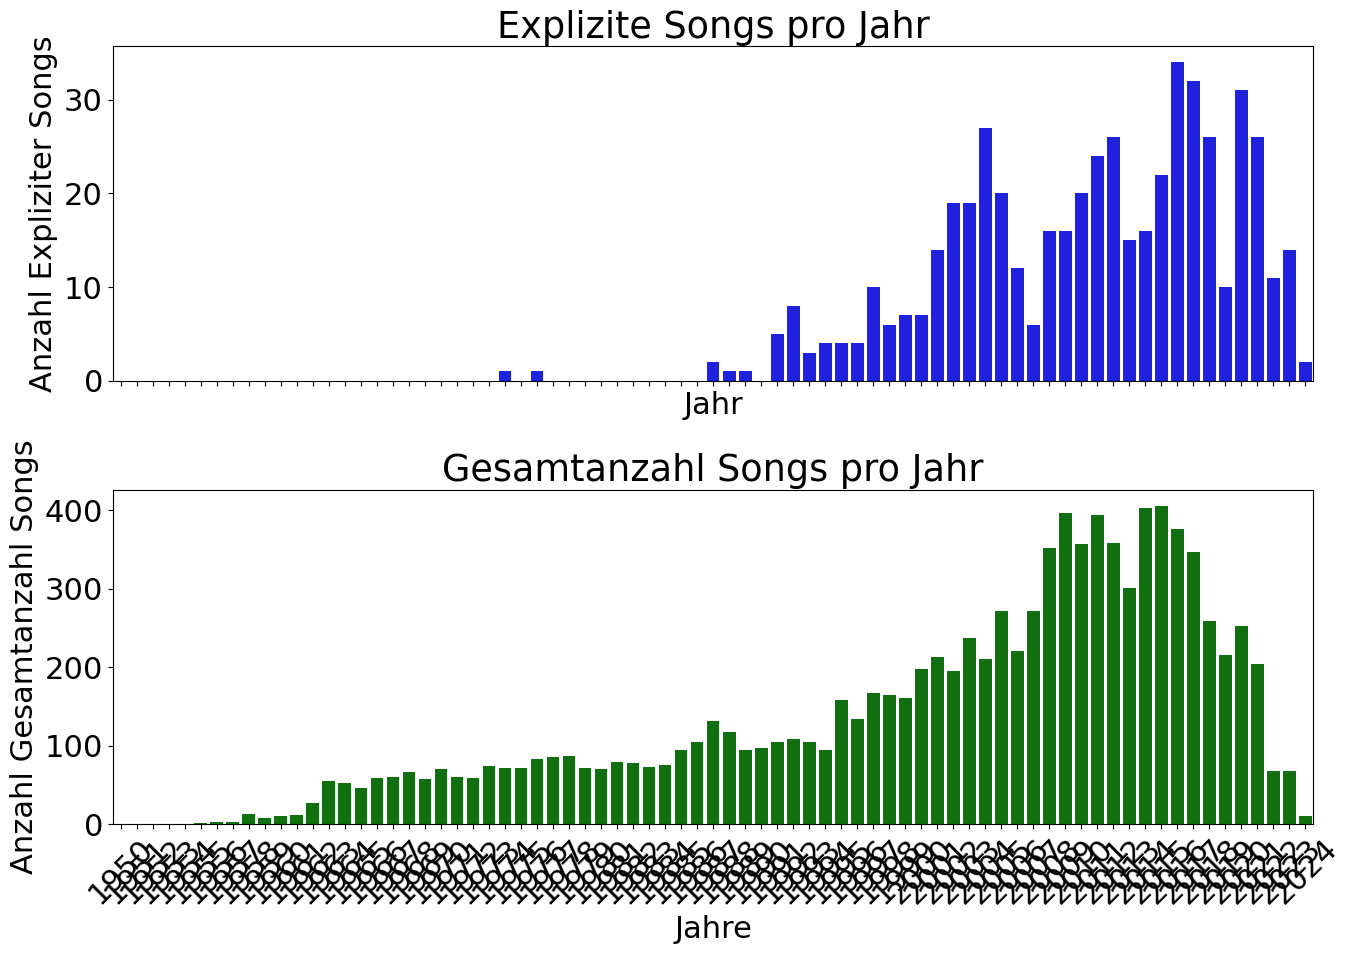

In [2]:
dataset = pd.read_csv("top_10000_1950-now.csv")
dataset = dataset.dropna(subset=['Album Release Date'], inplace=False)

data_explicit = dataset["Explicit"]
data_release_date = dataset["Album Release Date"]

df = pd.concat([data_explicit, data_release_date], axis=1)

count = [0] * 75
years = range(1950, 2025)
year_count = [0] * 75

for _, row in df.iterrows():
    year = int(row[1][0:4])
    tmp = year - 1950
    if row[0] == True:
        count[tmp] += 1
    if 1950 <= year <= 2025:
        year_count[tmp] += 1

data = pd.DataFrame({"Jahr": years, "Explizite Songs": count})
data_year_count = pd.DataFrame({"Jahr": years, "Gesamtanzahl Songs": year_count})

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
sns.barplot(ax=axes[0], x="Jahr", y="Explizite Songs", data=data, color="blue")
axes[0].set_title("Explizite Songs pro Jahr")
axes[0].set_ylabel("Anzahl Expliziter Songs")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(ax=axes[1], x="Jahr", y="Gesamtanzahl Songs", data=data_year_count, color="green")
axes[1].set_title("Gesamtanzahl Songs pro Jahr")
axes[1].set_xlabel("Jahre")
axes[1].set_ylabel("Anzahl Gesamtanzahl Songs")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

c:\Users\pawel\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\Users\pawel\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\pawel\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


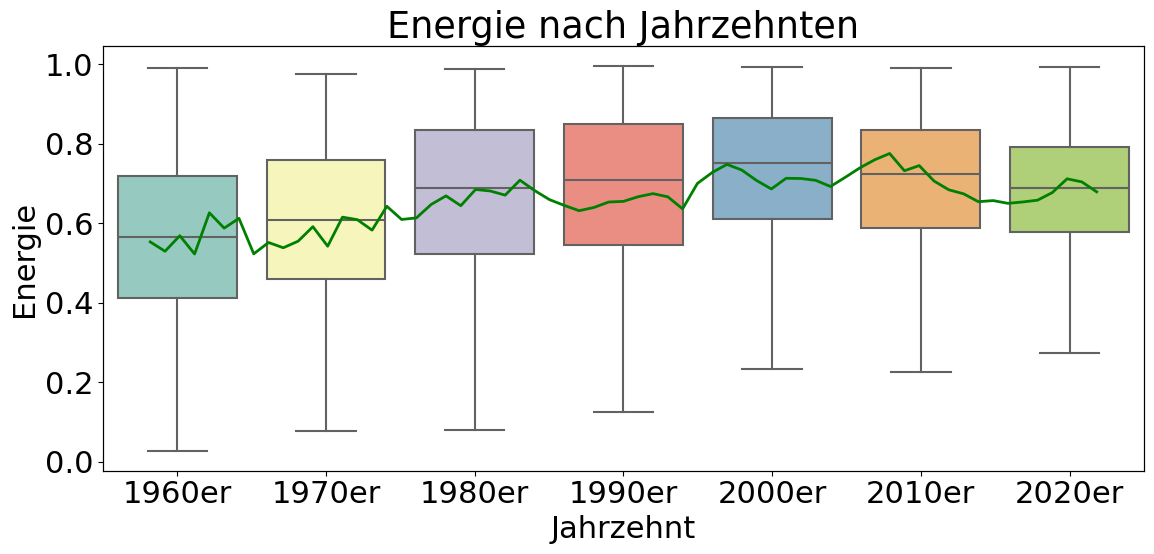

In [3]:
def assign_decade(year):
    if 1960 <= year < 1970:
        return "1960er"
    elif 1970 <= year < 1980:
        return "1970er"
    elif 1980 <= year < 1990:
        return "1980er"
    elif 1990 <= year < 2000:
        return "1990er"
    elif 2000 <= year < 2010:
        return "2000er"
    elif 2010 <= year < 2020:
        return "2010er"
    elif 2020 <= year < 2030:
        return "2020er"
    else:
        return None

dataset['Year'] = dataset['Album Release Date'].str[:4].astype(int)
dataset = dataset.sort_values(by=['Year'], ascending=True)
dataset['Decade'] = dataset['Year'].apply(assign_decade)
data = dataset['Energy'].rolling(window=20,step=1).mean()

dataset = dataset.dropna(subset=['Decade', 'Energy'])

ordered_decades = ["1960er", "1970er", "1980er", "1990er", "2000er", "2010er", "2020er"]
dataset['Decade'] = pd.Categorical(dataset['Decade'], categories=ordered_decades, ordered=True)


fig, ax1 = plt.subplots(figsize=(12, 6))

sns.boxplot(x='Decade', y='Energy', data=dataset, palette='Set3', showfliers=False, ax=ax1)
ax1.set_xlabel('Jahrzehnt')
ax1.set_ylabel('Energie')
ax1.set_title('Energie nach Jahrzehnten')

ax2 = ax1.twiny()  
ax2.set_xlabel('')
ax2.set_xticks([])
sns.lineplot(x=dataset['Year'], y=data, color='green', linewidth=2, ax=ax2,errorbar=None)


plt.tight_layout()
plt.savefig("energy", dpi=300)
plt.show()


c:\Users\pawel\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


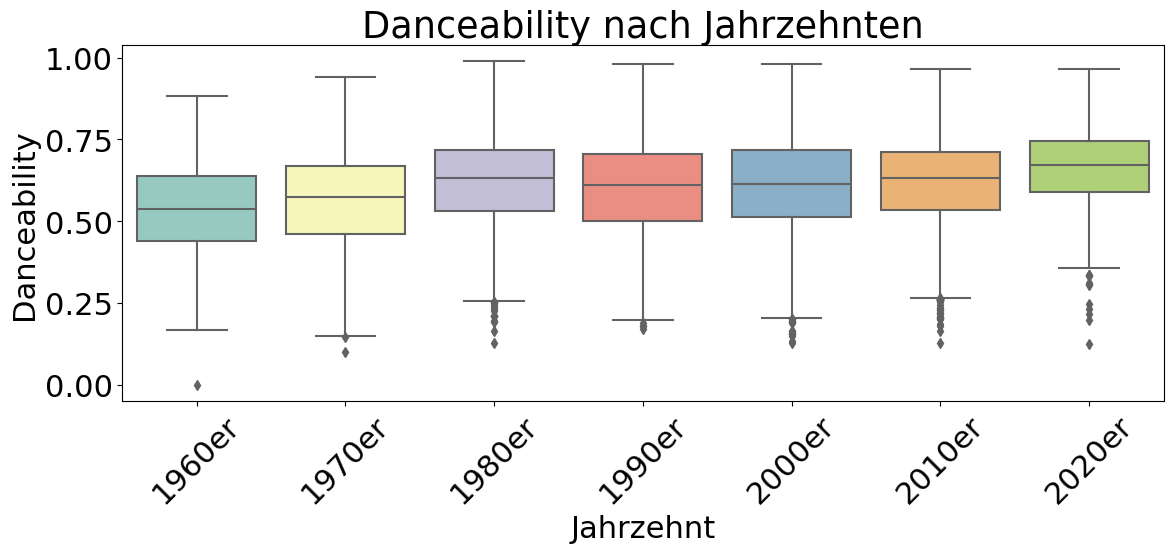

In [4]:
def assign_decade(year):
    if 1960 <= year < 1970:
        return "1960er"
    elif 1970 <= year < 1980:
        return "1970er"
    elif 1980 <= year < 1990:
        return "1980er"
    elif 1990 <= year < 2000:
        return "1990er"
    elif 2000 <= year < 2010:
        return "2000er"
    elif 2010 <= year < 2020:
        return "2010er"
    elif 2020 <= year < 2030:
        return "2020er"
    else:
        return None

dataset['Year'] = dataset['Album Release Date'].str[:4].astype(int)
dataset['Decade'] = dataset['Year'].apply(assign_decade)

dataset = dataset.dropna(subset=['Decade', 'Danceability'])

ordered_decades = ["1960er", "1970er", "1980er", "1990er", "2000er", "2010er", "2020er"]
dataset['Decade'] = pd.Categorical(dataset['Decade'], categories=ordered_decades, ordered=True)


plt.figure(figsize=(12, 6))
sns.boxplot(x='Decade', y='Danceability', data=dataset, palette='Set3')
plt.title('Danceability nach Jahrzehnten')
plt.xlabel('Jahrzehnt')
plt.ylabel('Danceability')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


c:\Users\pawel\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\pawel\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


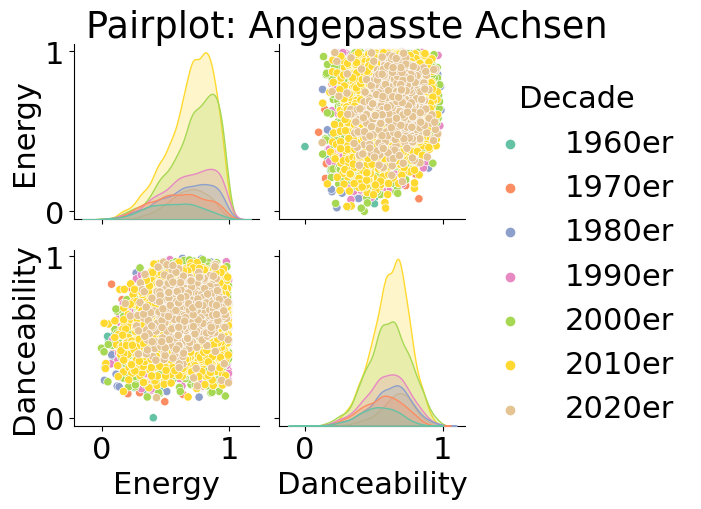

In [5]:
def assign_decade(year):
    if 1960 <= year < 1970:
        return "1960er"
    elif 1970 <= year < 1980:
        return "1970er"
    elif 1980 <= year < 1990:
        return "1980er"
    elif 1990 <= year < 2000:
        return "1990er"
    elif 2000 <= year < 2010:
        return "2000er"
    elif 2010 <= year < 2020:
        return "2010er"
    elif 2020 <= year < 2030:
        return "2020er"
    else:
        return None

dataset['Year'] = dataset['Album Release Date'].str[:4].astype(int)
dataset['Decade'] = dataset['Year'].apply(assign_decade)

subset = dataset.dropna(subset=['Danceability', 'Energy', 'Decade'])
subset = subset[['Danceability', 'Energy', 'Decade']]

sns.pairplot(
    data=subset,
    vars=['Energy', 'Danceability'],
    hue='Decade',
    diag_kind='kde',
    palette='Set2'
)
plt.suptitle('Pairplot: Angepasste Achsen', y=1.02)
plt.show()

c:\Users\pawel\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\Users\pawel\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\pawel\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


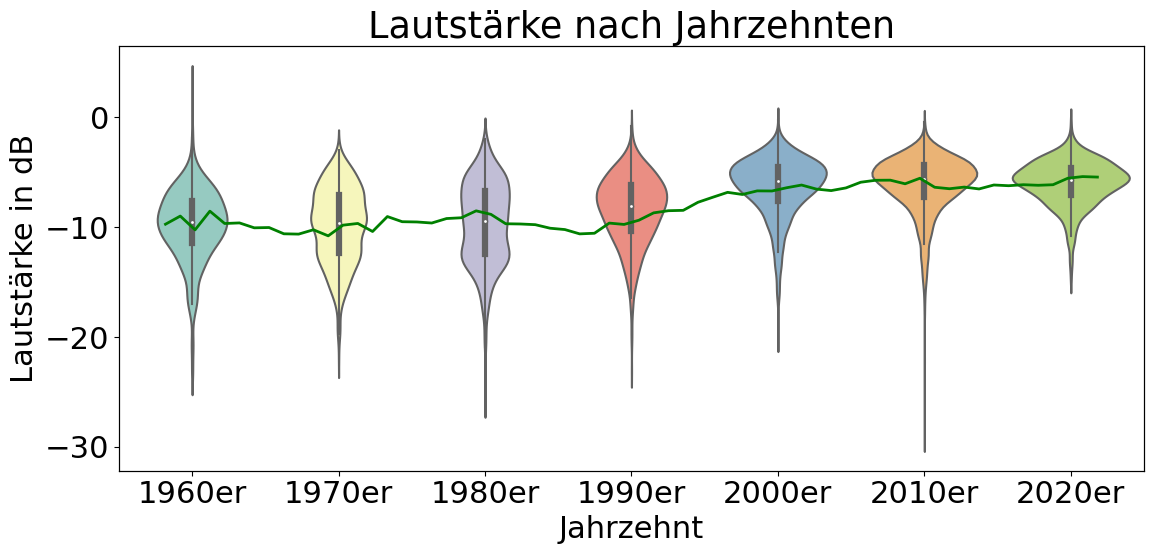

In [18]:
dataset['Year'] = dataset['Album Release Date'].str[:4].astype(int)
dataset = dataset.sort_values(by=['Year'], ascending=True)
dataset['Decade'] = dataset['Year'].apply(assign_decade)
data = dataset['Loudness'].rolling(window=20,step=1).mean()

dataset = dataset.dropna(subset=['Decade', 'Loudness'])

ordered_decades = ["1960er", "1970er", "1980er", "1990er", "2000er", "2010er", "2020er"]
dataset['Decade'] = pd.Categorical(dataset['Decade'], categories=ordered_decades, ordered=True)


fig, ax1 = plt.subplots(figsize=(12, 6))

#sns.boxplot(x='Decade', y='Loudness', data=dataset, palette='Set3', showfliers=False, ax=ax1)
sns.violinplot(x='Decade',y='Loudness',data=dataset,palette='Set3',ax=ax1)
ax1.set_xlabel('Jahrzehnt')
ax1.set_ylabel('Lautstärke in dB')
ax1.set_title('Lautstärke nach Jahrzehnten')

ax2 = ax1.twiny()  
ax2.set_xlabel('')
ax2.set_xticks([])
sns.lineplot(x=dataset['Year'], y=data, color='green', linewidth=2, ax=ax2,errorbar=None)


plt.tight_layout()
plt.savefig("loudness", dpi=300)
plt.show()

c:\Users\pawel\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\pawel\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


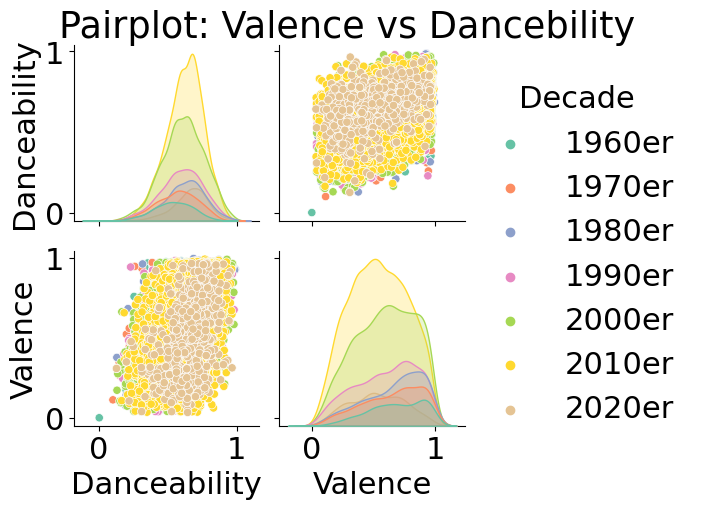

In [7]:
dataset['Year'] = dataset['Album Release Date'].str[:4].astype(int)
dataset['Decade'] = dataset['Year'].apply(assign_decade)

subset = dataset.dropna(subset=['Danceability', 'Energy', 'Decade','Valence'])
subset = subset[['Danceability', 'Energy', 'Decade','Valence']]

sns.pairplot(
    data=subset,
    vars=['Danceability', 'Valence'],
    hue='Decade',
    diag_kind='kde',
    palette='Set2'
)
plt.suptitle('Pairplot: Valence vs Dancebility', y=1.02)
plt.show()

c:\Users\pawel\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\pawel\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


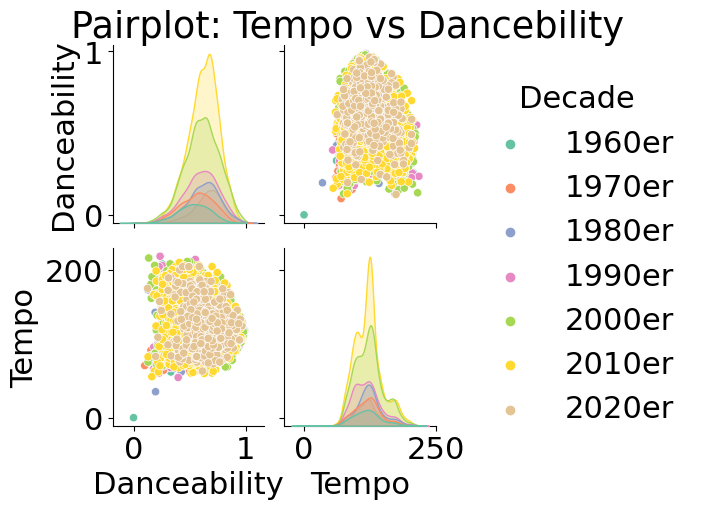

In [8]:
dataset['Year'] = dataset['Album Release Date'].str[:4].astype(int)
dataset['Decade'] = dataset['Year'].apply(assign_decade)

subset = dataset.dropna(subset=['Danceability', 'Tempo', 'Decade','Valence'])
subset = subset[['Danceability', 'Tempo', 'Decade','Valence']]

sns.pairplot(
    data=subset,
    vars=['Danceability', 'Tempo'],
    hue='Decade',
    diag_kind='kde',
    palette='Set2'
)
plt.suptitle('Pairplot: Tempo vs Dancebility', y=1.02)
plt.show()

c:\Users\pawel\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\Users\pawel\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\pawel\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


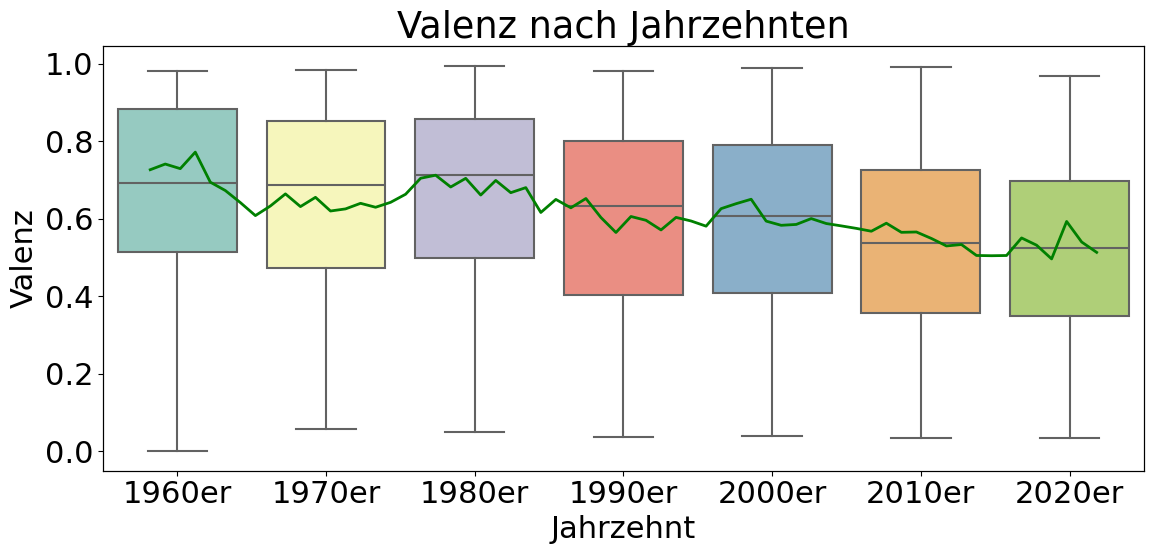

In [9]:
dataset['Year'] = dataset['Album Release Date'].str[:4].astype(int)
dataset = dataset.sort_values(by=['Year'], ascending=True)
dataset['Decade'] = dataset['Year'].apply(assign_decade)
data = dataset['Valence'].rolling(window=20,step=1).mean()


dataset = dataset.dropna(subset=['Decade', 'Valence'])

ordered_decades = ["1960er", "1970er", "1980er", "1990er", "2000er", "2010er", "2020er"]
dataset['Decade'] = pd.Categorical(dataset['Decade'], categories=ordered_decades, ordered=True)


fig, ax1 = plt.subplots(figsize=(12, 6))

# Boxplot auf der unteren X-Achse (Jahrzehnte)
sns.boxplot(x='Decade', y='Valence', data=dataset, palette='Set3', showfliers=False, ax=ax1)
ax1.set_xlabel('Jahrzehnt')
ax1.set_ylabel('Valenz')
ax1.set_title('Valenz nach Jahrzehnten')

ax2 = ax1.twiny()  
ax2.set_xlabel('')
ax2.set_xticks([])
sns.lineplot(x=dataset['Year'], y=data, color='green', linewidth=2, ax=ax2,errorbar=None)


plt.tight_layout()
plt.savefig("valence", dpi=300)
plt.show()

c:\Users\pawel\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\pawel\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


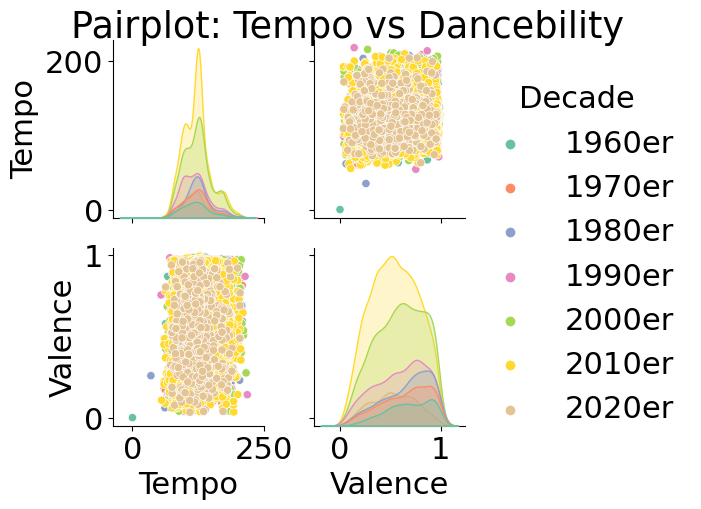

In [10]:
dataset['Year'] = dataset['Album Release Date'].str[:4].astype(int)
dataset['Decade'] = dataset['Year'].apply(assign_decade)

subset = dataset.dropna(subset=['Danceability', 'Tempo', 'Decade','Valence','Loudness'])
subset = subset[['Danceability', 'Tempo', 'Decade','Valence','Loudness']]

sns.pairplot(
    data=subset,
    vars=['Tempo', 'Valence'],
    hue='Decade',
    diag_kind='kde',
    palette='Set2'
)
plt.suptitle('Pairplot: Tempo vs Dancebility', y=1.02)
plt.show()

c:\Users\pawel\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\pawel\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


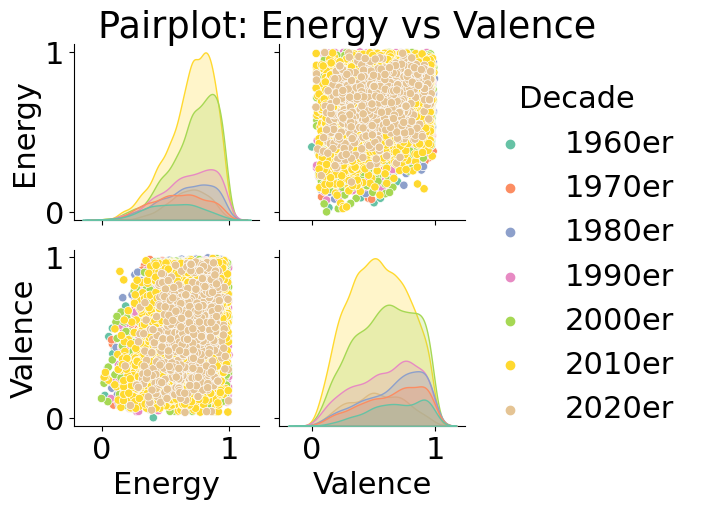

In [11]:
dataset['Year'] = dataset['Album Release Date'].str[:4].astype(int)
dataset['Decade'] = dataset['Year'].apply(assign_decade)

subset = dataset.dropna(subset=['Danceability', 'Tempo', 'Decade','Valence','Loudness','Energy'])
subset = subset[['Danceability', 'Tempo', 'Decade','Valence','Loudness','Energy']]

sns.pairplot(
    data=subset,
    vars=['Energy', 'Valence'],
    hue='Decade',
    diag_kind='kde',
    palette='Set2'
)
plt.suptitle('Pairplot: Energy vs Valence', y=1.02)
plt.show()

In [12]:
subset = dataset.dropna(subset=['Danceability', 'Tempo', 'Decade','Valence','Loudness','Energy'])
subset = subset[['Danceability', 'Tempo', 'Decade','Valence','Loudness','Energy']]

correlation,p_value = spearmanr(subset['Energy'],subset['Valence'])
print(f"Spearman Correlation: {correlation}, p-Value: {p_value}")

korrelation,p_wert = pearsonr(dataset['Energy'],dataset['Valence'])
print(f"Pearson Correlation: {korrelation}, p-Value: {p_wert}")



Spearman Correlation: 0.2556101418829296, p-Value: 1.9908131856938873e-148
Pearson Correlation: 0.2941118964907387, p-Value: 4.780394506921388e-198


H0: Kein Unterschied
Beobachtete Differenz: -0.07815447173287104
p-Wert: 0.0
Die Valence ist seit 2000 signifikant niedriger


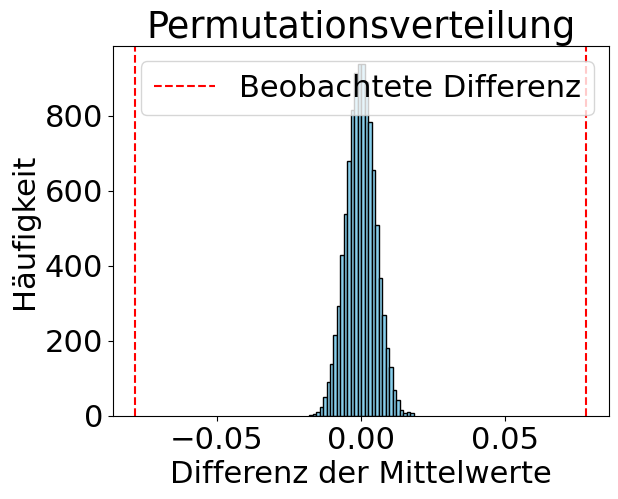

In [13]:
# Hypothesentest zur Untersuchung ob songs ab 2000 eine signifikant niedrigere Valence als songs zwischen 1950-1999 haben

subset = dataset.dropna(subset=['Album Release Date', 'Valence','Year'])
subset = subset[['Year','Album Release Date','Valence','Decade']]
data_1950_1999 = []
data_2000_now = []


for _,entry in subset.iterrows():
    if entry['Decade'] == "2000er" or entry['Decade'] == "2010er" or entry['Decade'] == "2020er":
        data_2000_now.append(entry['Valence'])
    else:
        data_1950_1999.append(entry['Valence'])

observed_difference = np.mean(data_2000_now) - np.mean(data_1950_1999)

data = np.concatenate([data_1950_1999, data_2000_now])
n1 = len(data_1950_1999)
n2 = len(data_2000_now)

n_permutations = 10000
differences = []
counter = 0

for _ in range(n_permutations):
    np.random.shuffle(data)
    new_difference = np.mean(data[:n1]) - np.mean(data[n1:])
    differences.append(new_difference)

for value in differences:
    if np.abs(value) >= np.abs(observed_difference):
        counter += 1
p_value = counter / n_permutations

print("H0: Kein Unterschied")
print(f"Beobachtete Differenz: {observed_difference}")
print(f"p-Wert: {p_value}")

if p_value < 0.05:
    print("Die Valence ist seit 2000 signifikant niedriger")
else:
    print("Kein signifikanter Unterschied in der Valence")

plt.hist(differences, bins=30, color='skyblue', edgecolor='black')
plt.axvline(observed_difference, color='red', linestyle='dashed', linewidth=1.5, label='Beobachtete Differenz')
plt.axvline(-observed_difference, color='red', linestyle='dashed', linewidth=1.5)
plt.title('Permutationsverteilung')
plt.xlabel('Differenz der Mittelwerte')
plt.ylabel('Häufigkeit')
plt.legend()
plt.savefig("permutation.png",dpi=300)
plt.show()







H0: Kein Unterschied
Beobachtete Differenz: 0.05742990937812298
p-Wert: 0.0
Die Valence ist seit 2000 signifikant höher


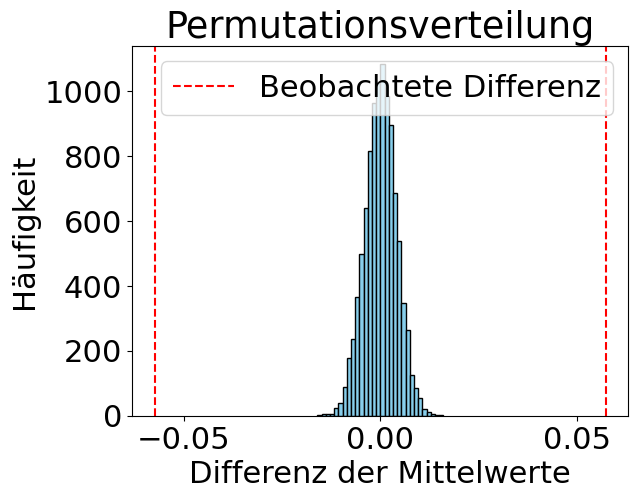

In [14]:
subset = dataset.dropna(subset=['Album Release Date', 'Valence','Year','Energy'])
subset = subset[['Year','Album Release Date','Valence','Decade','Energy']]
data_1950_1999 = []
data_2000_now = []


for _,entry in subset.iterrows():
    if entry['Decade'] == "2000er" or entry['Decade'] == "2010er" or entry['Decade'] == "2020er":
        data_2000_now.append(entry['Energy'])
    else:
        data_1950_1999.append(entry['Energy'])

observed_difference = np.mean(data_2000_now) - np.mean(data_1950_1999)

data = np.concatenate([data_1950_1999, data_2000_now])
n1 = len(data_1950_1999)
n2 = len(data_2000_now)

n_permutations = 10000
differences = []
counter = 0

for _ in range(n_permutations):
    np.random.shuffle(data)
    new_difference = np.mean(data[:n1]) - np.mean(data[n1:])
    differences.append(new_difference)

for value in differences:
    if np.abs(value) >= np.abs(observed_difference):
        counter += 1
p_value = counter / n_permutations

print("H0: Kein Unterschied")
print(f"Beobachtete Differenz: {observed_difference}")
print(f"p-Wert: {p_value}")

if p_value < 0.05:
    print("Die Valence ist seit 2000 signifikant höher")
else:
    print("Kein signifikanter Unterschied in der Valence")

plt.hist(differences, bins=30, color='skyblue', edgecolor='black')
plt.axvline(observed_difference, color='red', linestyle='dashed', linewidth=1.5, label='Beobachtete Differenz')
plt.axvline(-observed_difference, color='red', linestyle='dashed', linewidth=1.5)
plt.title('Permutationsverteilung')
plt.xlabel('Differenz der Mittelwerte')
plt.ylabel('Häufigkeit')
plt.legend()
plt.show()

3387
6579
H0: Kein Unterschied
Beobachtete Differenz: 3.048154493233496
p-Wert: 0.0
Die Loudness ist seit 2000 signifikant Höher


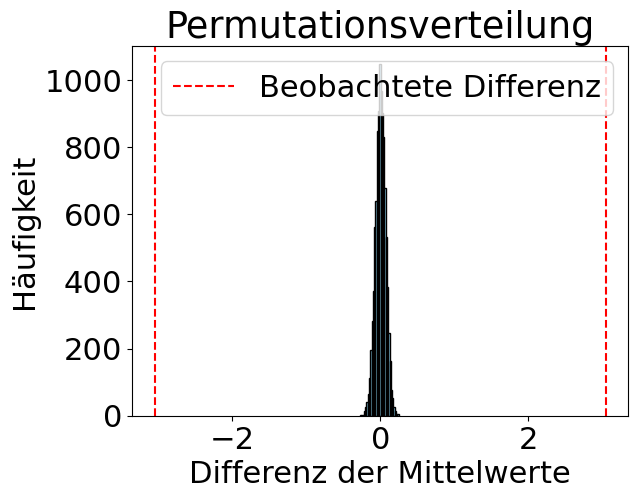

In [15]:
subset = dataset.dropna(subset=['Album Release Date', 'Valence','Year','Loudness'])
subset = subset[['Year','Album Release Date','Valence','Decade','Loudness']]
data_1950_1999 = []
data_2000_now = []


for _,entry in subset.iterrows():
    if entry['Decade'] == "2000er" or entry['Decade'] == "2010er" or entry['Decade'] == "2020er":
        data_2000_now.append(entry['Loudness'])
    else:
        data_1950_1999.append(entry['Loudness'])

observed_difference = np.mean(data_2000_now) - np.mean(data_1950_1999)

data = np.concatenate([data_1950_1999, data_2000_now])
n1 = len(data_1950_1999)
n2 = len(data_2000_now)
print(n1)
print(n2)

n_permutations = 10000
differences = []
counter = 0

for _ in range(n_permutations):
    np.random.shuffle(data)
    new_difference = np.mean(data[:n1]) - np.mean(data[n1:])
    differences.append(new_difference)

for value in differences:
    if np.abs(value) >= np.abs(observed_difference):
        counter += 1
p_value = counter / n_permutations

print("H0: Kein Unterschied")
print(f"Beobachtete Differenz: {observed_difference}")
print(f"p-Wert: {p_value}")

if p_value < 0.05:
    print("Die Loudness ist seit 2000 signifikant Höher")
else:
    print("Kein signifikanter Unterschied in der Loduness")

plt.hist(differences, bins=30, color='skyblue', edgecolor='black')
plt.axvline(observed_difference, color='red', linestyle='dashed', linewidth=1.5, label='Beobachtete Differenz')
plt.axvline(-observed_difference, color='red', linestyle='dashed', linewidth=1.5)
plt.title('Permutationsverteilung')
plt.xlabel('Differenz der Mittelwerte')
plt.ylabel('Häufigkeit')
plt.legend()
plt.show()

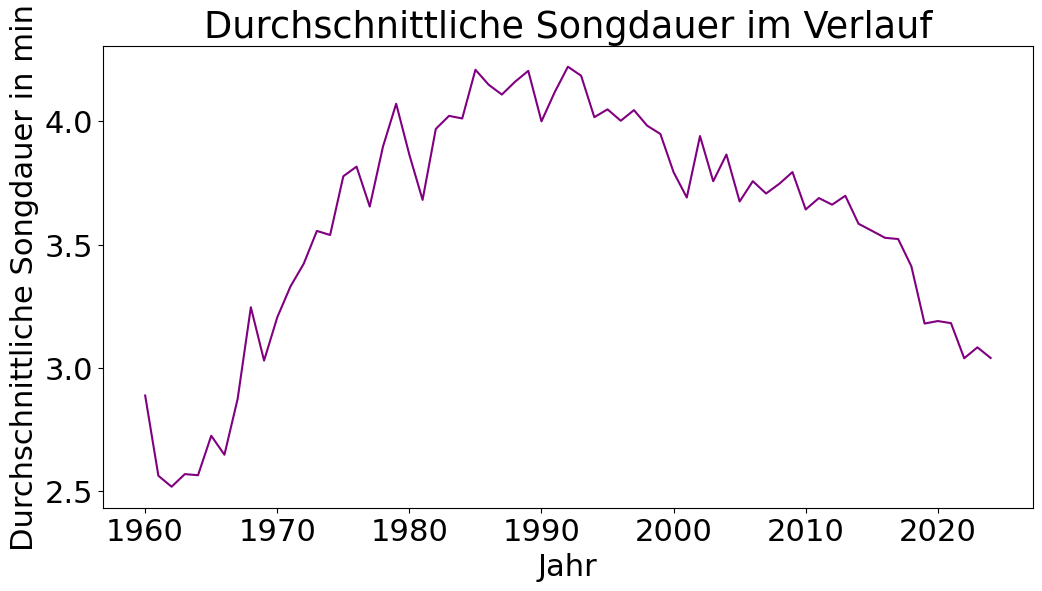

In [16]:
dataset['Track Duration (min)'] = dataset['Track Duration (ms)'] / 60000
avg_duration = dataset.groupby('Year')['Track Duration (min)'].median()

plt.figure(figsize=(12, 6))
avg_duration.plot(color='purple')
plt.title('Durchschnittliche Songdauer im Verlauf')
plt.xlabel('Jahr')
plt.ylabel('Durchschnittliche Songdauer in min')
plt.savefig("songdauer", dpi=300)
plt.show()


In [17]:
mean_1950_1999 = np.mean(data_1950_1999)
mean_2000_now = np.mean(data_2000_now)

std_1950_1999 = np.std(data_1950_1999, ddof=1)
std_2000_now = np.std(data_2000_now, ddof=1)

n_1950_1999 = len(data_1950_1999)
n_2000_now = len(data_2000_now)

pooled_std = np.sqrt(
    ((n_1950_1999 - 1) * std_1950_1999**2 + (n_2000_now - 1) * std_2000_now**2) / 
    (n_1950_1999 + n_2000_now - 2)
)

cohens_d = (mean_2000_now - mean_1950_1999) / pooled_std

print(f"Cohen's d: {cohens_d}")


Cohen's d: 1.0362998414380038
